# 04 Feature + Confidence 1/2 Weighted Loss MLP

`up_sampling_confi4` 결과를 보면 confidence 1/2를 살리는 방법으로는 오버샘플링보다 loss weighting이 더 안정적이었다.

이 노트북은 `04_similarity_feature_mlp_confidence.ipynb`와 같은 입력/모델 구조를 쓰되, confidence 1과 2 샘플에 더 큰 loss weight를 준다.

- 입력: audio embedding + text embedding + class one-hot + similarity/margin scalar 4개
- 모델: Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)
- 5-class: confidence 1/2 샘플에 weighted loss 적용
- Binary: confidence 123 vs 45, 단 confidence 1/2 샘플에 weighted loss 적용

In [1]:
from pathlib import Path
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 128
EPOCHS = 120
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 32
DROPOUT = 0.2
LABELS = [1, 2, 3, 4, 5]

# From up_sampling_confi4/w_loss_12_345 result.
# These weights raise confidence 1 and 2 to roughly the confidence-4 train-count scale.
CONFIDENCE_LOSS_WEIGHTS = {
    1: 20.540625,
    2: 2.927839643652561,
    3: 1.0,
    4: 1.0,
    5: 1.0,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('DEVICE:', DEVICE)

DEVICE: cuda


## 경로 설정

In [2]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd().resolve()

if HERE.name == 'deft논문기반_실험':
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

METADATA_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
TEXT_SIM_CSV = EXP_DIR / 'audio_text_sim_confidence_outputs' / 'audio_text_similarity_with_bin_predictions.csv'
CLASS_SIM_CSV = EXP_DIR / 'audio_class_sim_confidence_outputs' / 'audio_class_similarity_with_bin_predictions.csv'
MARGIN_CSV = EXP_DIR / 'clap_similarity_margin_outputs' / 'clap_similarity_margin_features.csv'

OUT_DIR = EXP_DIR / 'weighted_loss_confidence12_outputs'
PLOT_DIR = OUT_DIR / 'plots'
REPORT_DIR = OUT_DIR / 'reports'
PRED_DIR = OUT_DIR / 'predictions'
MODEL_DIR = OUT_DIR / 'models'
for p in [OUT_DIR, PLOT_DIR, REPORT_DIR, PRED_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('EXP_DIR:', EXP_DIR)
print('OUT_DIR:', OUT_DIR)
for p in [METADATA_CSV, AUDIO_EMB_DIR, TEXT_EMB_DIR, TEXT_SIM_CSV, CLASS_SIM_CSV, MARGIN_CSV]:
    print(p, 'exists:', p.exists())

ROOT: C:\Users\solok\Desktop\Dcase baseline
EXP_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험
OUT_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\weighted_loss_confidence12_outputs
C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_text_sim_confidence_outputs\audio_text_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\audio_class_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\clap_similarity_margin_features.csv exists: True


## 04와 동일한 feature 생성

In [3]:
SCALAR_FEATURE_COLS = [
    'audio_text_sim',
    'audio_class_sim',
    'audio_assigned_label_margin',
    'text_assigned_label_margin',
]
FEATURE_DESCRIPTION = 'audio_embedding_512 + text_embedding_512 + class_one_hot + similarity_margin_4'
MODEL_DESCRIPTION = 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)'

meta = pd.read_csv(METADATA_CSV)
audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows = []
audio_list = []
text_list = []
missing_audio = 0
missing_text = 0
invalid_confidence = 0

for _, row in meta.iterrows():
    sound_id = str(row['sound_id'])
    audio_path = audio_paths.get(sound_id)
    text_path = text_paths.get(sound_id)
    if audio_path is None:
        missing_audio += 1
        continue
    if text_path is None:
        missing_text += 1
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        invalid_confidence += 1
        continue
    if confidence not in LABELS:
        invalid_confidence += 1
        continue
    rows.append({'sound_id': sound_id, 'class': row['class'], 'confidence': confidence})
    audio_list.append(np.load(audio_path).reshape(-1).astype(np.float32))
    text_list.append(np.load(text_path).reshape(-1).astype(np.float32))

df = pd.DataFrame(rows)
df['_row_idx'] = np.arange(len(df))
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

text_sim_df = pd.read_csv(TEXT_SIM_CSV)[['sound_id', 'audio_text_sim']]
class_sim_df = pd.read_csv(CLASS_SIM_CSV)[['sound_id', 'audio_class_sim']]
margin_df = pd.read_csv(MARGIN_CSV)[['sound_id', 'audio_assigned_label_margin', 'text_assigned_label_margin']]
for part_df in [text_sim_df, class_sim_df, margin_df]:
    part_df['sound_id'] = part_df['sound_id'].astype(str)

df = df.merge(text_sim_df, on='sound_id', how='left')
df = df.merge(class_sim_df, on='sound_id', how='left')
df = df.merge(margin_df, on='sound_id', how='left')
missing_scalar = int(df[SCALAR_FEATURE_COLS].isna().any(axis=1).sum())
df = df.dropna(subset=SCALAR_FEATURE_COLS).reset_index(drop=True)

keep_idx = df['_row_idx'].to_numpy(dtype=np.int64)
audio_emb = audio_emb[keep_idx]
text_emb = text_emb[keep_idx]
scalar_features = df[SCALAR_FEATURE_COLS].to_numpy(dtype=np.float32)

class_categories = sorted(df['class'].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(class_categories)}
class_ids = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
class_onehot = np.eye(len(class_categories), dtype=np.float32)[class_ids]

X_full = np.concatenate([audio_emb, text_emb, class_onehot, scalar_features], axis=1).astype(np.float32)
y_confidence = df['confidence'].to_numpy(dtype=np.int64)
y_5class = y_confidence - 1
y_binary = (y_confidence >= 4).astype(np.int64)
df['class_idx'] = class_ids
df['binary_confidence'] = y_binary
df = df.drop(columns=['_row_idx'])

df.to_csv(REPORT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')
np.save(REPORT_DIR / 'X_audio_text_class_similarity_margin.npy', X_full)
(REPORT_DIR / 'class_mapping.json').write_text(json.dumps(class_to_idx, indent=2, ensure_ascii=False), encoding='utf-8')

print('rows:', len(df))
print('missing audio:', missing_audio)
print('missing text:', missing_text)
print('invalid confidence:', invalid_confidence)
print('missing scalar features:', missing_scalar)
print('X_full:', X_full.shape)
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

rows: 10956
missing audio: 0
missing text: 0
invalid confidence: 0
missing scalar features: 0
X_full: (10956, 1051)


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


## Split, scaling, loss weights

In [4]:
idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y_confidence)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y_confidence[temp_idx])

split_df = pd.DataFrame({'sound_id': df['sound_id'], 'split': 'train'})
split_df.loc[val_idx, 'split'] = 'val'
split_df.loc[test_idx, 'split'] = 'test'
split_df.to_csv(REPORT_DIR / 'splits.csv', index=False, encoding='utf-8-sig')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[train_idx]).astype(np.float32)
X_val = scaler.transform(X_full[val_idx]).astype(np.float32)
X_test = scaler.transform(X_full[test_idx]).astype(np.float32)

train_conf = y_confidence[train_idx]
val_conf = y_confidence[val_idx]
test_conf = y_confidence[test_idx]
train_sample_weights = np.array([CONFIDENCE_LOSS_WEIGHTS[int(c)] for c in train_conf], dtype=np.float32)
val_sample_weights = np.ones(len(val_idx), dtype=np.float32)

weight_plan = pd.DataFrame({
    'confidence': LABELS,
    'train_count': [int((train_conf == c).sum()) for c in LABELS],
    'loss_weight': [CONFIDENCE_LOSS_WEIGHTS[c] for c in LABELS],
})
weight_plan.to_csv(REPORT_DIR / 'confidence12_loss_weight_plan.csv', index=False, encoding='utf-8-sig')

print('train/val/test:', len(train_idx), len(val_idx), len(test_idx))
display(pd.crosstab(split_df['split'], df['confidence'], rownames=['split'], colnames=['confidence']))
display(weight_plan)

train/val/test: 7669 1643 1644


confidence,1,2,3,4,5
split,,,,,
test,16,112,492,907,117
train,74,524,2296,4232,543
val,16,113,492,906,116


,confidence,train_count,loss_weight
0,1,74,20.540625
1,2,524,2.927840
2,3,2296,1.000000
3,4,4232,1.000000
4,5,543,1.000000


## Model and weighted training

In [5]:
class OneLayerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

def make_loader(X_arr, y_arr, weight_arr=None, batch_size=BATCH_SIZE, shuffle=False):
    if weight_arr is None:
        weight_arr = np.ones(len(y_arr), dtype=np.float32)
    ds = TensorDataset(
        torch.from_numpy(X_arr),
        torch.from_numpy(y_arr.astype(np.int64)),
        torch.from_numpy(weight_arr.astype(np.float32)),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def weighted_cross_entropy(logits, y, sample_weight):
    per_sample_loss = nn.functional.cross_entropy(logits, y, reduction='none')
    return (per_sample_loss * sample_weight).sum() / sample_weight.sum().clamp_min(1e-8)

def compute_metrics(y_true, y_pred, one_based_mae=False):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    if one_based_mae:
        mae = mean_absolute_error(y_true + 1, y_pred + 1)
    else:
        mae = mean_absolute_error(y_true, y_pred)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': p_macro,
        'macro_recall': r_macro,
        'macro_f1': f1_macro,
        'weighted_precision': p_weighted,
        'weighted_recall': r_weighted,
        'weighted_f1': f1_weighted,
        'mae': mae,
    }

def train_weighted_mlp(task_name, X_train, y_train, X_val, y_val, train_weights, output_dim, one_based_mae=False):
    seed_everything(SEED)
    model = OneLayerMLP(X_train.shape[1], output_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader(X_train, y_train, train_weights, shuffle=True)
    val_loader = make_loader(X_val, y_val, np.ones(len(y_val), dtype=np.float32), shuffle=False)

    history = []
    best_state = None
    best_epoch = None
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        train_weight_sum = 0.0
        for xb, yb, wb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            wb = wb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = weighted_cross_entropy(logits, yb, wb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * float(wb.sum().item())
            train_weight_sum += float(wb.sum().item())
        train_loss = train_loss_sum / max(train_weight_sum, 1e-8)

        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        all_true = []
        all_pred = []
        with torch.no_grad():
            for xb, yb, wb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = nn.functional.cross_entropy(logits, yb, reduction='mean')
                pred = logits.argmax(dim=1)
                val_loss_sum += loss.item() * len(yb)
                n_val += len(yb)
                all_true.append(yb.cpu().numpy())
                all_pred.append(pred.cpu().numpy())
        val_loss = val_loss_sum / n_val
        y_true_epoch = np.concatenate(all_true)
        y_pred_epoch = np.concatenate(all_pred)
        epoch_metrics = compute_metrics(y_true_epoch, y_pred_epoch, one_based_mae=one_based_mae)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, **epoch_metrics})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"{task_name} {epoch:03d}/{EPOCHS} train_loss={train_loss:.4f} val_loss={val_loss:.4f} acc={epoch_metrics['accuracy']:.4f} mae={epoch_metrics['mae']:.4f} f1={epoch_metrics['macro_f1']:.4f}")

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(REPORT_DIR / f'{task_name}_history.csv', index=False, encoding='utf-8-sig')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df['epoch'], history_df['train_loss'], label='weighted train loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='validation loss')
    ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'best epoch {best_epoch}')
    ax.set_title(f'{task_name} loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('cross entropy')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'{task_name}_loss_curve.png', dpi=180)
    plt.show()

    return model, history_df, {'best_epoch': best_epoch, 'best_val_loss': best_val_loss}

def predict(model, X_arr):
    loader = DataLoader(torch.from_numpy(X_arr), batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds = []
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            probs.append(prob)
            preds.append(prob.argmax(axis=1))
    return np.concatenate(preds), np.concatenate(probs)

def plot_cm(cm, labels, title, path):
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm, vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.show()
    return cm_norm

## 5-class weighted classification

confidence_5class_weighted12_mlp 001/120 train_loss=1.3683 val_loss=1.1338 acc=0.5350 mae=0.5953 f1=0.2916
confidence_5class_weighted12_mlp 002/120 train_loss=1.1766 val_loss=1.0834 acc=0.5320 mae=0.6068 f1=0.3092
confidence_5class_weighted12_mlp 003/120 train_loss=1.1126 val_loss=1.0730 acc=0.5350 mae=0.5983 f1=0.2998
confidence_5class_weighted12_mlp 004/120 train_loss=1.0498 val_loss=1.0436 acc=0.5514 mae=0.5624 f1=0.3270
confidence_5class_weighted12_mlp 005/120 train_loss=1.0048 val_loss=1.0364 acc=0.5496 mae=0.5679 f1=0.3165
confidence_5class_weighted12_mlp 006/120 train_loss=0.9811 val_loss=1.0289 acc=0.5484 mae=0.5551 f1=0.3355
confidence_5class_weighted12_mlp 007/120 train_loss=0.9402 val_loss=1.0498 acc=0.5332 mae=0.5995 f1=0.3233
confidence_5class_weighted12_mlp 008/120 train_loss=0.9123 val_loss=1.0232 acc=0.5447 mae=0.5654 f1=0.3185
confidence_5class_weighted12_mlp 009/120 train_loss=0.8999 val_loss=1.0368 acc=0.5453 mae=0.5642 f1=0.3158
confidence_5class_weighted12_mlp 010/

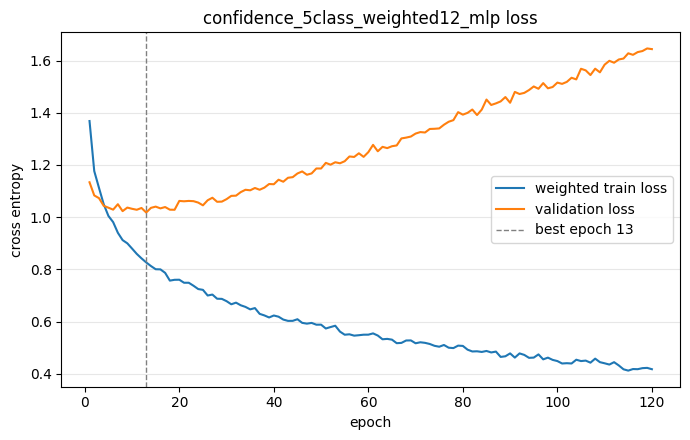

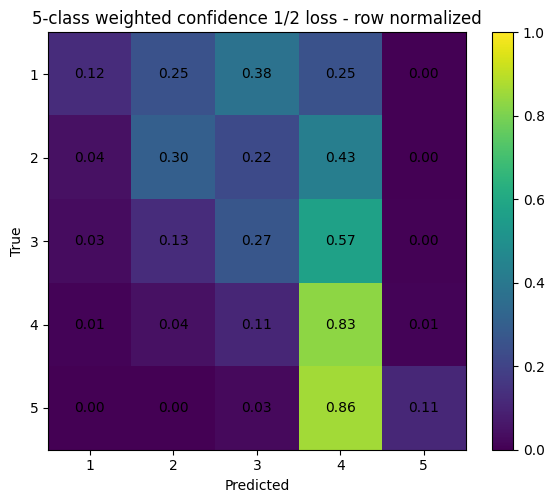

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,task,best_epoch,best_val_loss
0,0.5675,0.401,0.3272,0.3211,0.557,0.5675,0.5332,0.5182,confidence_5class_weighted12_mlp,13,1.0179


,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,2,4,6,4,0
true_2,5,34,25,48,0
true_3,16,62,131,281,2
true_4,9,40,97,753,8
true_5,0,0,3,101,13


              precision    recall  f1-score   support

confidence_1     0.0625    0.1250    0.0833        16
confidence_2     0.2429    0.3036    0.2698       112
confidence_3     0.5000    0.2663    0.3475       492
confidence_4     0.6344    0.8302    0.7192       907
confidence_5     0.5652    0.1111    0.1857       117

    accuracy                         0.5675      1644
   macro avg     0.4010    0.3272    0.3211      1644
weighted avg     0.5570    0.5675    0.5332      1644



In [6]:
y5_train = y_5class[train_idx]
y5_val = y_5class[val_idx]
y5_test = y_5class[test_idx]

model_5class, history_5class, best_5class = train_weighted_mlp(
    task_name='confidence_5class_weighted12_mlp',
    X_train=X_train,
    y_train=y5_train,
    X_val=X_val,
    y_val=y5_val,
    train_weights=train_sample_weights,
    output_dim=5,
    one_based_mae=True,
)

pred5, prob5 = predict(model_5class, X_test)
true5 = y5_test
metrics_5class = compute_metrics(true5, pred5, one_based_mae=True)
metrics_5class.update({'task': 'confidence_5class_weighted12_mlp', **best_5class})
metrics_5class_df = pd.DataFrame([metrics_5class])

true5_label = true5 + 1
pred5_label = pred5 + 1
cm5 = confusion_matrix(true5_label, pred5_label, labels=LABELS)
cm5_df = pd.DataFrame(cm5, index=[f'true_{x}' for x in LABELS], columns=[f'pred_{x}' for x in LABELS])
cm5_norm = plot_cm(cm5, LABELS, '5-class weighted confidence 1/2 loss - row normalized', PLOT_DIR / 'confidence_5class_weighted12_confusion_row_normalized.png')

report5_text = classification_report(true5_label, pred5_label, labels=LABELS, target_names=[f'confidence_{x}' for x in LABELS], digits=4, zero_division=0)
report5_dict = classification_report(true5_label, pred5_label, labels=LABELS, target_names=[f'confidence_{x}' for x in LABELS], output_dict=True, zero_division=0)

metrics_5class_df.to_csv(REPORT_DIR / 'confidence_5class_weighted12_metrics.csv', index=False, encoding='utf-8-sig')
cm5_df.to_csv(REPORT_DIR / 'confidence_5class_weighted12_confusion_counts.csv', encoding='utf-8-sig')
pd.DataFrame(cm5_norm, index=cm5_df.index, columns=cm5_df.columns).to_csv(REPORT_DIR / 'confidence_5class_weighted12_confusion_row_normalized.csv', encoding='utf-8-sig')
(REPORT_DIR / 'confidence_5class_weighted12_classification_report.txt').write_text(report5_text, encoding='utf-8')
pd.DataFrame(report5_dict).T.to_csv(REPORT_DIR / 'confidence_5class_weighted12_classification_report.csv', encoding='utf-8-sig')

pred5_df = pd.DataFrame({'sound_id': df.loc[test_idx, 'sound_id'].values, 'true_confidence': true5_label, 'pred_confidence': pred5_label, 'correct': true5_label == pred5_label, 'pred_confidence_prob': prob5.max(axis=1)})
for i in range(5):
    pred5_df[f'prob_confidence_{i + 1}'] = prob5[:, i]
pred5_df.to_csv(PRED_DIR / 'confidence_5class_weighted12_test_predictions.csv', index=False, encoding='utf-8-sig')

torch.save({'model_state_dict': model_5class.state_dict(), 'feature_description': FEATURE_DESCRIPTION, 'model_description': MODEL_DESCRIPTION, 'loss_weights': CONFIDENCE_LOSS_WEIGHTS, 'metrics': metrics_5class}, MODEL_DIR / 'confidence_5class_weighted12_mlp.pt')

display(metrics_5class_df.round(4))
display(cm5_df)
print(report5_text)

## Binary weighted classification: confidence 123 vs 45

confidence_binary_123_vs_45_weighted12_mlp 001/120 train_loss=0.6111 val_loss=0.6276 acc=0.6354 mae=0.3646 f1=0.6307
confidence_binary_123_vs_45_weighted12_mlp 002/120 train_loss=0.5393 val_loss=0.6073 acc=0.6519 mae=0.3481 f1=0.6453
confidence_binary_123_vs_45_weighted12_mlp 003/120 train_loss=0.5175 val_loss=0.5976 acc=0.6689 mae=0.3311 f1=0.6595
confidence_binary_123_vs_45_weighted12_mlp 004/120 train_loss=0.4897 val_loss=0.5894 acc=0.6817 mae=0.3183 f1=0.6678
confidence_binary_123_vs_45_weighted12_mlp 005/120 train_loss=0.4803 val_loss=0.5941 acc=0.6878 mae=0.3122 f1=0.6770
confidence_binary_123_vs_45_weighted12_mlp 006/120 train_loss=0.4691 val_loss=0.5990 acc=0.6732 mae=0.3268 f1=0.6614
confidence_binary_123_vs_45_weighted12_mlp 007/120 train_loss=0.4557 val_loss=0.5960 acc=0.6829 mae=0.3171 f1=0.6689
confidence_binary_123_vs_45_weighted12_mlp 008/120 train_loss=0.4510 val_loss=0.6120 acc=0.6713 mae=0.3287 f1=0.6581
confidence_binary_123_vs_45_weighted12_mlp 009/120 train_loss=0.

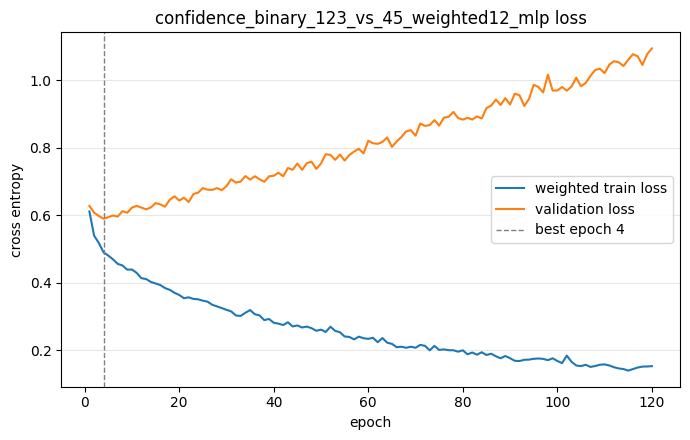

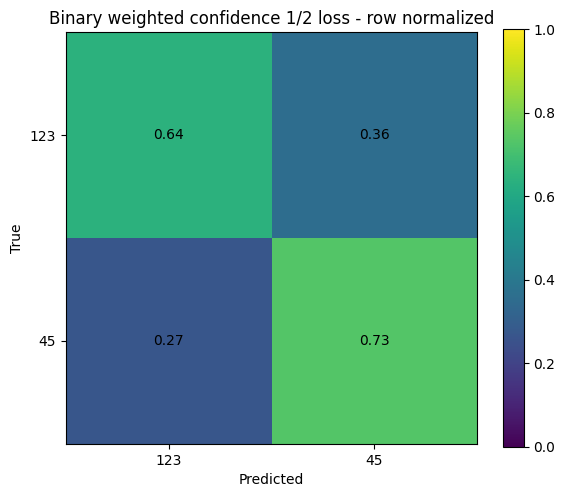

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,task,best_epoch,best_val_loss
0,0.6989,0.6825,0.6877,0.6844,0.7044,0.6989,0.701,0.3011,confidence_binary_123_vs_45_weighted12_mlp,4,0.5894


,pred_123,pred_45
true_123,398,222
true_45,273,751


                precision    recall  f1-score   support

confidence_123     0.5931    0.6419    0.6166       620
 confidence_45     0.7718    0.7334    0.7521      1024

      accuracy                         0.6989      1644
     macro avg     0.6825    0.6877    0.6844      1644
  weighted avg     0.7044    0.6989    0.7010      1644



In [7]:
yb_train = y_binary[train_idx]
yb_val = y_binary[val_idx]
yb_test = y_binary[test_idx]

model_binary, history_binary, best_binary = train_weighted_mlp(
    task_name='confidence_binary_123_vs_45_weighted12_mlp',
    X_train=X_train,
    y_train=yb_train,
    X_val=X_val,
    y_val=yb_val,
    train_weights=train_sample_weights,
    output_dim=2,
    one_based_mae=False,
)

predb, probb = predict(model_binary, X_test)
trueb = yb_test
metrics_binary = compute_metrics(trueb, predb, one_based_mae=False)
metrics_binary.update({'task': 'confidence_binary_123_vs_45_weighted12_mlp', **best_binary})
metrics_binary_df = pd.DataFrame([metrics_binary])

binary_labels = [0, 1]
binary_names = ['123', '45']
cmb = confusion_matrix(trueb, predb, labels=binary_labels)
cmb_df = pd.DataFrame(cmb, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45'])
cmb_norm = plot_cm(cmb, binary_names, 'Binary weighted confidence 1/2 loss - row normalized', PLOT_DIR / 'confidence_binary_weighted12_confusion_row_normalized.png')

reportb_text = classification_report(trueb, predb, labels=binary_labels, target_names=['confidence_123', 'confidence_45'], digits=4, zero_division=0)
reportb_dict = classification_report(trueb, predb, labels=binary_labels, target_names=['confidence_123', 'confidence_45'], output_dict=True, zero_division=0)

metrics_binary_df.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_weighted12_metrics.csv', index=False, encoding='utf-8-sig')
cmb_df.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_weighted12_confusion_counts.csv', encoding='utf-8-sig')
pd.DataFrame(cmb_norm, index=cmb_df.index, columns=cmb_df.columns).to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_weighted12_confusion_row_normalized.csv', encoding='utf-8-sig')
(REPORT_DIR / 'confidence_binary_123_vs_45_weighted12_classification_report.txt').write_text(reportb_text, encoding='utf-8')
pd.DataFrame(reportb_dict).T.to_csv(REPORT_DIR / 'confidence_binary_123_vs_45_weighted12_classification_report.csv', encoding='utf-8-sig')

predb_df = pd.DataFrame({'sound_id': df.loc[test_idx, 'sound_id'].values, 'true_binary_confidence': trueb, 'pred_binary_confidence': predb, 'correct': trueb == predb, 'prob_123': probb[:, 0], 'prob_45': probb[:, 1], 'original_confidence': test_conf})
predb_df.to_csv(PRED_DIR / 'confidence_binary_123_vs_45_weighted12_test_predictions.csv', index=False, encoding='utf-8-sig')

torch.save({'model_state_dict': model_binary.state_dict(), 'feature_description': FEATURE_DESCRIPTION, 'model_description': MODEL_DESCRIPTION, 'loss_weights': CONFIDENCE_LOSS_WEIGHTS, 'metrics': metrics_binary}, MODEL_DIR / 'confidence_binary_123_vs_45_weighted12_mlp.pt')

display(metrics_binary_df.round(4))
display(cmb_df)
print(reportb_text)

## Summary

In [8]:
all_metrics = pd.concat([metrics_5class_df, metrics_binary_df], ignore_index=True)
all_metrics.to_csv(REPORT_DIR / 'all_weighted12_mlp_metrics.csv', index=False, encoding='utf-8-sig')

summary = {
    'choice': 'weighted_loss_confidence_1_2',
    'reason': 'up_sampling_confi4 results favored confidence12 weighted loss over oversampling for this minority-confidence objective',
    'feature_description': FEATURE_DESCRIPTION,
    'model_description': MODEL_DESCRIPTION,
    'loss_weights': CONFIDENCE_LOSS_WEIGHTS,
    'input_dim': int(X_full.shape[1]),
    'metrics': json.loads(all_metrics.to_json(orient='records')),
}
(REPORT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

report_lines = []
report_lines.append('# Confidence 1/2 Weighted Loss Report')
report_lines.append('')
report_lines.append('## Choice')
report_lines.append('- Selected weighted loss over oversampling.')
report_lines.append('- `up_sampling_confi4` showed `12 vs 345` weighted loss had better/stabler macro F1 than the confidence-1-only setup, while oversampling/XGBoost hurt 5-class MAE strongly.')
report_lines.append('')
report_lines.append('## Loss weights')
report_lines.append(weight_plan.to_string(index=False))
report_lines.append('')
report_lines.append('## Metrics')
report_lines.append('```text')
report_lines.append(all_metrics.round(4).to_string(index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## 5-class report')
report_lines.append('```text')
report_lines.append(report5_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## Binary report')
report_lines.append('```text')
report_lines.append(reportb_text)
report_lines.append('```')
(REPORT_DIR / 'weighted12_mlp_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

display(all_metrics.round(4))
print('saved:', OUT_DIR)

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,task,best_epoch,best_val_loss
0,0.5675,0.4010,0.3272,0.3211,0.5570,0.5675,0.5332,0.5182,confidence_5class_weighted12_mlp,13,1.0179
1,0.6989,0.6825,0.6877,0.6844,0.7044,0.6989,0.7010,0.3011,confidence_binary_123_vs_45_weighted12_mlp,4,0.5894


saved: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\weighted_loss_confidence12_outputs
